In [2]:
# INSTALL LIBRARIES
!pip install tensorflow opencv-python matplotlib numpy pandas

In [1]:
# IMPORT LIBRARIES
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

In [3]:
# LOAD DATASET
!kaggle datasets download -d gti-upm/leapgestrecog

Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [00:22<00:00, 102MB/s] 



In [4]:
# EXTRACT DATASET
import zipfile

with zipfile.ZipFile("leapgestrecog.zip", "r") as zip_ref:
    zip_ref.extractall("/content/gesture_data")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
# CHECK FOLDER STRUCTURE
import os

print(os.listdir("/content/gesture_data"))

['leapGestRecog', 'leapgestrecog']


In [6]:
# LOAD IMAGES
import os
import cv2
import numpy as np

data = []
labels = []

dataset_path = "/content/gesture_data/leapGestRecog"

for subject in os.listdir(dataset_path):

    subject_path = os.path.join(dataset_path, subject)

    for gesture in os.listdir(subject_path):

        gesture_path = os.path.join(subject_path, gesture)

        for img_name in os.listdir(gesture_path):

            img_path = os.path.join(gesture_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                img = cv2.resize(img, (64,64))
                data.append(img.flatten())
                labels.append(gesture)

print("Total Images:", len(data))

Total Images: 20000


In [7]:
# CONVERT TO NUMPY ARRAYS
X = np.array(data) / 255.0
y = np.array(labels)

print(X.shape)
print(y.shape)

(20000, 4096)
(20000,)


In [8]:
# SPLIT DATASET
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
# TRAIN SVM
from sklearn.svm import SVC

svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

print("Training Completed")

Training Completed


In [17]:
# EVALUATE MODEL
from sklearn.metrics import accuracy_score, classification_report

y_pred = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.99925
               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       418
         02_l       1.00      1.00      1.00       366
      03_fist       1.00      1.00      1.00       404
04_fist_moved       1.00      1.00      1.00       392
     05_thumb       1.00      1.00      1.00       409
     06_index       1.00      1.00      1.00       410
        07_ok       1.00      1.00      1.00       403
08_palm_moved       1.00      1.00      1.00       377
         09_c       1.00      1.00      1.00       404
      10_down       1.00      1.00      1.00       417

     accuracy                           1.00      4000
    macro avg       1.00      1.00      1.00      4000
 weighted avg       1.00      1.00      1.00      4000



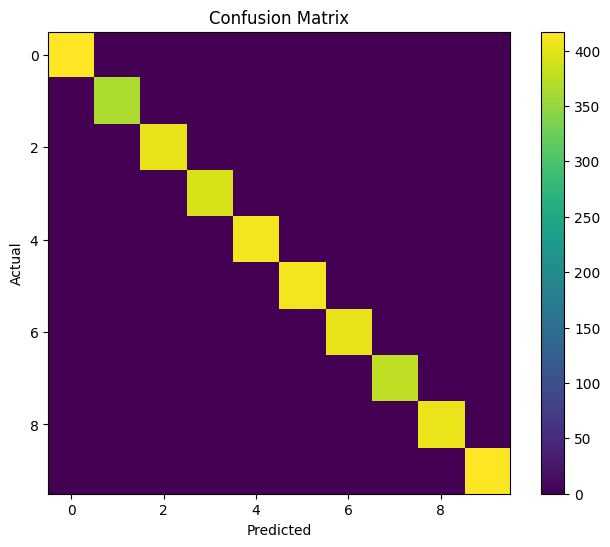

In [18]:
# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
import os

print(os.listdir())

['.config', 'leapgestrecog.zip', 'gesture_data', 'sample_data']


In [14]:
# UPLOAD TEST IMAGE
from google.colab import files

uploaded = files.upload()

Saving HAND.jpeg to HAND.jpeg


In [15]:
filename = list(uploaded.keys())[0]

img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

print(img.shape)

(743, 847)


In [19]:
# PREDICT GESTURE
test_img = cv2.imread(list(uploaded.keys())[0], cv2.IMREAD_GRAYSCALE)

test_img = cv2.resize(test_img, (64,64))

test_array = test_img.flatten().reshape(1,-1)
test_array = test_array / 255.0

prediction = svm.predict(test_array)

print("Predicted Gesture:", prediction[0])

Predicted Gesture: 05_thumb


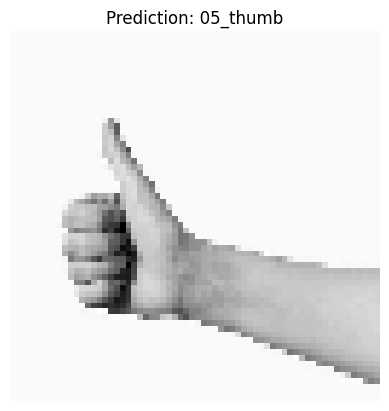

In [20]:
# SHOW IMAGE
import matplotlib.pyplot as plt

plt.imshow(test_img, cmap='gray')
plt.title(f"Prediction: {prediction[0]}")
plt.axis("off")
plt.show()